In [ ]:
# notebooks/03_model_training.ipynb

import sys
sys.path.insert(0, '../src')

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── clear cached modules if re-running ───────────────────────────────────────
import importlib, sys as _sys
for mod in ['config','data_loader','preprocessor','trainer','evaluator']:
    _sys.modules.pop(mod, None)

from data_loader  import (load_raw_data, clean_dependents,
                           handle_credit_history, encode_target,
                           get_X_y, get_train_val_split)
from trainer      import train_all_models, save_model
from evaluator    import (evaluate_all_models, plot_confusion_matrices,
                           plot_roc_curves, plot_metric_comparison)

# ── 1. Load and prepare ──────────────────────────────────────────────────────
df, _ = load_raw_data()
df = clean_dependents(df)
df = handle_credit_history(df)
df = encode_target(df)

X, y = get_X_y(df)
X_train, X_val, y_train, y_val = get_train_val_split(X, y)

print(f"Training on {X_train.shape[0]} samples, validating on {X_val.shape[0]}")

# ── 2. Train all models ──────────────────────────────────────────────────────
print("\nTraining all models:")
fitted_pipelines = train_all_models(X_train, y_train)

# ── 3. Save all models ───────────────────────────────────────────────────────
print("\nSaving models:")
for name, pipeline in fitted_pipelines.items():
    save_model(pipeline, name)

# ── 4. Evaluate ──────────────────────────────────────────────────────────────
print("\nEvaluation results:")
results_df = evaluate_all_models(fitted_pipelines, X_val, y_val)
print(results_df.to_string())

# ── 5. Visualize ─────────────────────────────────────────────────────────────
plot_confusion_matrices(fitted_pipelines, X_val, y_val)
plot_roc_curves(fitted_pipelines, X_val, y_val)
plot_metric_comparison(results_df)

In [ ]:
# Check if XGBoost needs a version fix
import xgboost as xgb
print("XGBoost version:", xgb.__version__)
# If you get a warning about use_label_encoder, remove that parameter
# from get_models() — it was deprecated in XGBoost >= 1.6

In [ ]:
from sklearn.metrics import accuracy_score

train_pred = fitted_pipelines['DecisionTree'].predict(X_train)
val_pred = fitted_pipelines['DecisionTree'].predict(X_val)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Validation Accuracy:", accuracy_score(y_val, val_pred))

In [ ]:
print(results_df.to_string())

In [ ]:
# Run this entire cell before touching any other code
# It will find the bug by inspecting what the pipeline actually sees

import sys
sys.path.insert(0, '../src')

# Clear module cache
for mod in list(sys.modules.keys()):
    if mod in ('config','data_loader','preprocessor','trainer','evaluator'):
        del sys.modules[mod]

import numpy as np
import pandas as pd
from data_loader  import (load_raw_data, clean_dependents,
                           handle_credit_history, encode_target,
                           get_X_y, get_train_val_split)
from preprocessor import build_preprocessor

df, _ = load_raw_data()
df    = clean_dependents(df)
df    = handle_credit_history(df)
df    = encode_target(df)

X, y = get_X_y(df)
X_train, X_val, y_train, y_val = get_train_val_split(X, y)

# ── CHECK 1: What columns reach the preprocessor? ────────────────────────────
print("=== CHECK 1: Columns entering the pipeline ===")
print(X_train.columns.tolist())
print(f"Shape: {X_train.shape}")

# ── CHECK 2: Is Credit_History present and correct? ──────────────────────────
print("\n=== CHECK 2: Credit_History distribution ===")
print(X_train['Credit_History'].value_counts(dropna=False))
# Expected: 1.0 (majority), 0.0, -1.0 (our MNAR fill)
# If you see NaN still present, handle_credit_history didn't run

# ── CHECK 3: Is Dependents numeric? ──────────────────────────────────────────
print("\n=== CHECK 3: Dependents dtype and values ===")
print(f"dtype: {X_train['Dependents'].dtype}")
print(X_train['Dependents'].value_counts(dropna=False))
# Expected: dtype float64 or int, values 0/1/2/3

# ── CHECK 4: What does the preprocessor output look like? ────────────────────
print("\n=== CHECK 4: Preprocessed output ===")
preprocessor = build_preprocessor()
X_proc = preprocessor.fit_transform(X_train)
print(f"Shape after preprocessing: {X_proc.shape}")
print(f"Any NaN in output: {np.isnan(X_proc).any()}")
print(f"Any Inf in output: {np.isinf(X_proc).any()}")
print(f"First row sample:  {X_proc[0].round(3)}")

# ── CHECK 5: Target sanity ────────────────────────────────────────────────────
print("\n=== CHECK 5: Target variable ===")
print(f"y_train dtype:  {y_train.dtype}")
print(f"y_train values: {y_train.value_counts().to_dict()}")
print(f"y_val values:   {y_val.value_counts().to_dict()}")
# Expected: {1: ~338, 0: ~154} for train

# ── CHECK 6: Quick logistic regression manual check ──────────────────────────
print("\n=== CHECK 6: Manual LR probability check ===")
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('pre', build_preprocessor()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
pipe.fit(X_train, y_train)

probs = pipe.predict_proba(X_val)[:, 1]
print(f"Probability range: [{probs.min():.3f}, {probs.max():.3f}]")
print(f"Probability mean:  {probs.mean():.3f}")
print(f"Prob distribution: {np.percentile(probs, [10,25,50,75,90]).round(3)}")
# If range is narrow (e.g., all between 0.60-0.75), the model has no
# discriminative power — confirms the pipeline is losing signal

In [1]:
# Run this verification cell first — don't retrain until this passes

import sys, importlib
for mod in list(sys.modules.keys()):
    if mod in ('config','data_loader','preprocessor','trainer','evaluator'):
        del sys.modules[mod]
sys.path.insert(0, '../src')

import numpy as np
from data_loader  import (load_raw_data, clean_dependents,
                           handle_credit_history, encode_target,
                           get_X_y, get_train_val_split)
from preprocessor import build_preprocessor

df, _ = load_raw_data()
df    = clean_dependents(df)
df    = handle_credit_history(df)
df    = encode_target(df)
X, y  = get_X_y(df)
X_train, X_val, y_train, y_val = get_train_val_split(X, y)

preprocessor = build_preprocessor()
X_proc       = preprocessor.fit_transform(X_train)

# ── Verification checks ───────────────────────────────────────────────────────
print("=== POST-FIX VERIFICATION ===\n")

print(f"Input columns  : {X_train.shape[1]}")
print(f"Output columns : {X_proc.shape[1]}")

# Credit_History + Dependents = 2 extra columns vs before
# Before: 10 columns. After: should be 12
# Exact count: 4 numerical + ~8 one-hot categoricals + 2 passthrough = ~14
assert X_proc.shape[1] > 10, "Still dropping features — check config.py"

print(f"\nAny NaN : {np.isnan(X_proc).any()}")
print(f"Any Inf : {np.isinf(X_proc).any()}")
assert not np.isnan(X_proc).any(), "NaN found — imputation failed"
assert not np.isinf(X_proc).any(), "Inf found — log transform failed"

# Print every feature name so you can confirm Credit_History is present
feature_names = preprocessor.get_feature_names_out()
print(f"\nFeatures in model ({len(feature_names)} total):")
for name in feature_names:
    print(f"  {name}")

# Confirm Credit_History and Dependents are in the list
ch_present  = any('Credit_History' in n for n in feature_names)
dep_present = any('Dependents'     in n for n in feature_names)
print(f"\nCredit_History in pipeline : {ch_present}")
print(f"Dependents     in pipeline : {dep_present}")
assert ch_present,  "Credit_History still missing — bug not fixed"
assert dep_present, "Dependents still missing — bug not fixed"

print("\n✓ All checks passed — safe to retrain")

=== POST-FIX VERIFICATION ===

Input columns  : 12
Output columns : 12

Any NaN : False
Any Inf : False

Features in model (12 total):
  num__ApplicantIncome
  num__CoapplicantIncome
  num__LoanAmount
  num__Loan_Amount_Term
  cat__Gender_Male
  cat__Married_Yes
  cat__Education_Not Graduate
  cat__Self_Employed_Yes
  cat__Property_Area_Semiurban
  cat__Property_Area_Urban
  pass__Credit_History
  pass__Dependents

Credit_History in pipeline : True
Dependents     in pipeline : True

✓ All checks passed — safe to retrain


Retraining all models with fixed pipeline:

  Training LogisticRegression... done
  Training DecisionTree... done
  Training RandomForest... done
  Training GradientBoosting... done
  Training XGBoost... 

c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:12:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


done
  Saved: c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\notebooks\..\models\LogisticRegression.joblib
  Saved: c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\notebooks\..\models\DecisionTree.joblib
  Saved: c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\notebooks\..\models\RandomForest.joblib
  Saved: c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\notebooks\..\models\GradientBoosting.joblib
  Saved: c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\notebooks\..\models\XGBoost.joblib

── Results after fix ──
                    accuracy  precision  recall      f1  roc_auc
model                                                           
RandomForest          0.8455     0.8438  0.9529  0.8950   0.8214
DecisionTree          0.8130     0.8229  0.9294  0.8729   0.7746
XGBoost               0.7886     0.8172  0.8941  0.8539   0.7731
GradientBoosting      0.8374     0.8351  0.9529  0.8901   0.7557
LogisticRegression    0.6

c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be remove

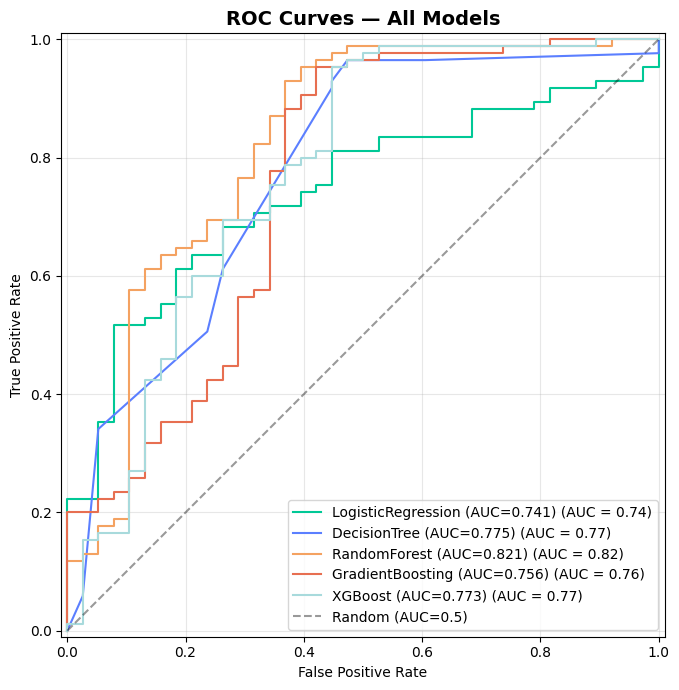

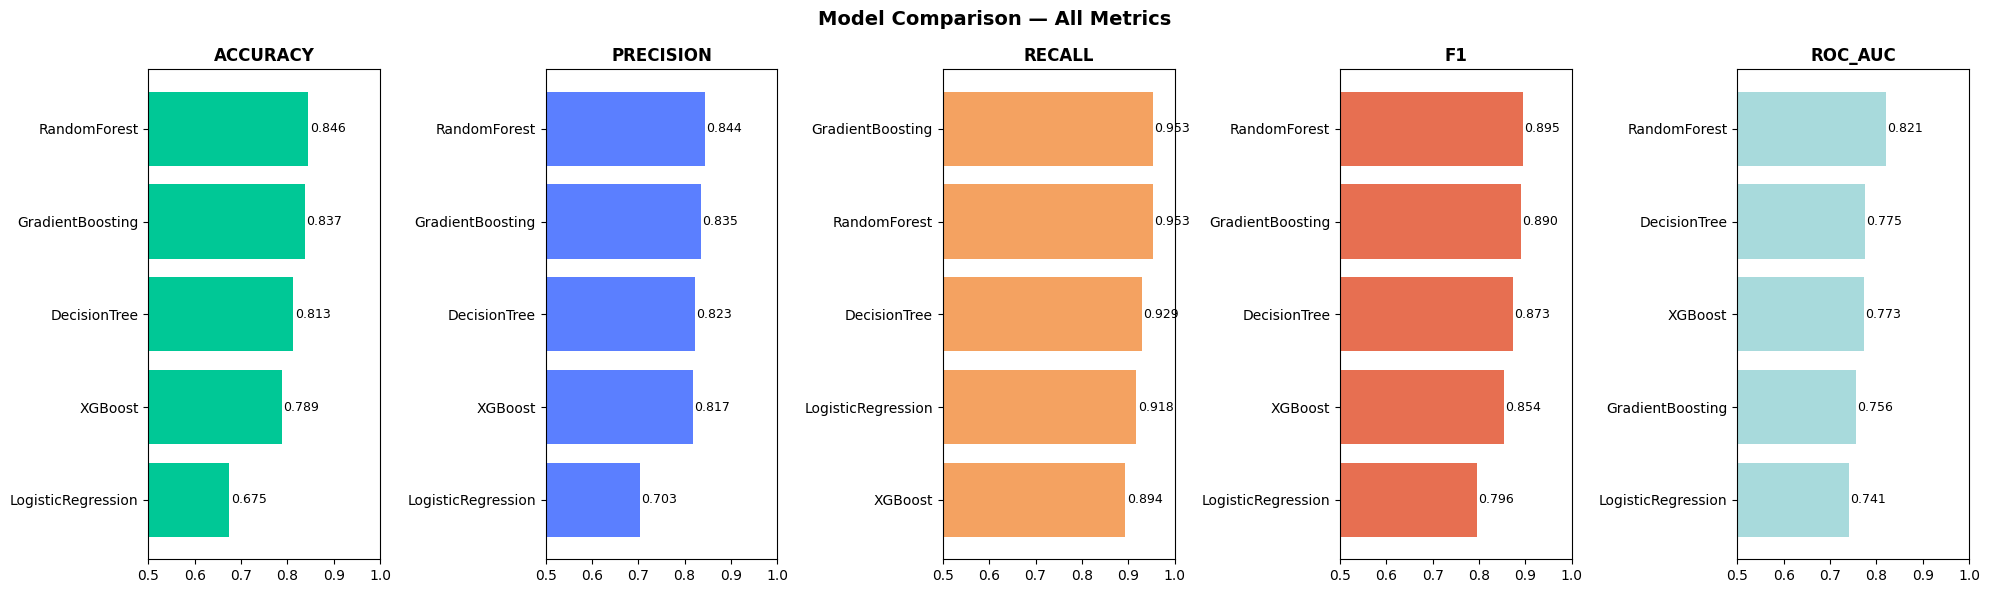

In [2]:
# Full retrain after fix
from trainer   import train_all_models, save_model
from evaluator import evaluate_all_models, plot_roc_curves, plot_metric_comparison

print("Retraining all models with fixed pipeline:\n")
fitted_pipelines = train_all_models(X_train, y_train)

for name, pipeline in fitted_pipelines.items():
    save_model(pipeline, name)

results_df = evaluate_all_models(fitted_pipelines, X_val, y_val)
print("\n── Results after fix ──")
print(results_df.to_string())

plot_roc_curves(fitted_pipelines, X_val, y_val)
plot_metric_comparison(results_df)

Retraining all models:

  Training LogisticRegression... done
  Training DecisionTree... done
  Training RandomForest... done
  Training GradientBoosting... done
  Training XGBoost... done
  Saved: c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\notebooks\..\models\LogisticRegression.joblib
  Saved: c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\notebooks\..\models\DecisionTree.joblib
  Saved: c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\notebooks\..\models\RandomForest.joblib
  Saved: c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\notebooks\..\models\GradientBoosting.joblib


c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:15:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Saved: c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\notebooks\..\models\XGBoost.joblib

── Results after fix ──
                    accuracy  precision  recall      f1  roc_auc
model                                                           
RandomForest          0.8455     0.8438  0.9529  0.8950   0.8214
DecisionTree          0.8130     0.8229  0.9294  0.8729   0.7746
XGBoost               0.7886     0.8172  0.8941  0.8539   0.7731
GradientBoosting      0.8374     0.8351  0.9529  0.8901   0.7557
LogisticRegression    0.6748     0.7027  0.9176  0.7959   0.7412


c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Shresth\OneDrive\Desktop\loan-eligibility-predictor\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be remove

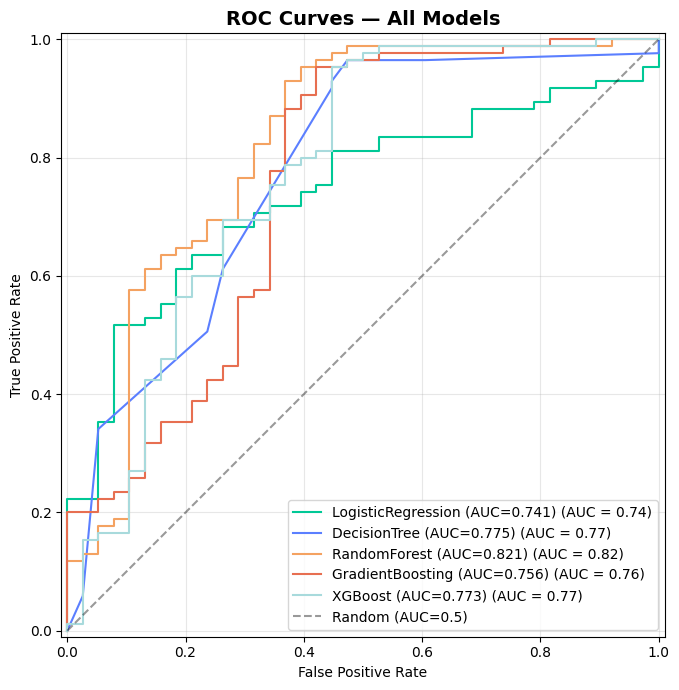

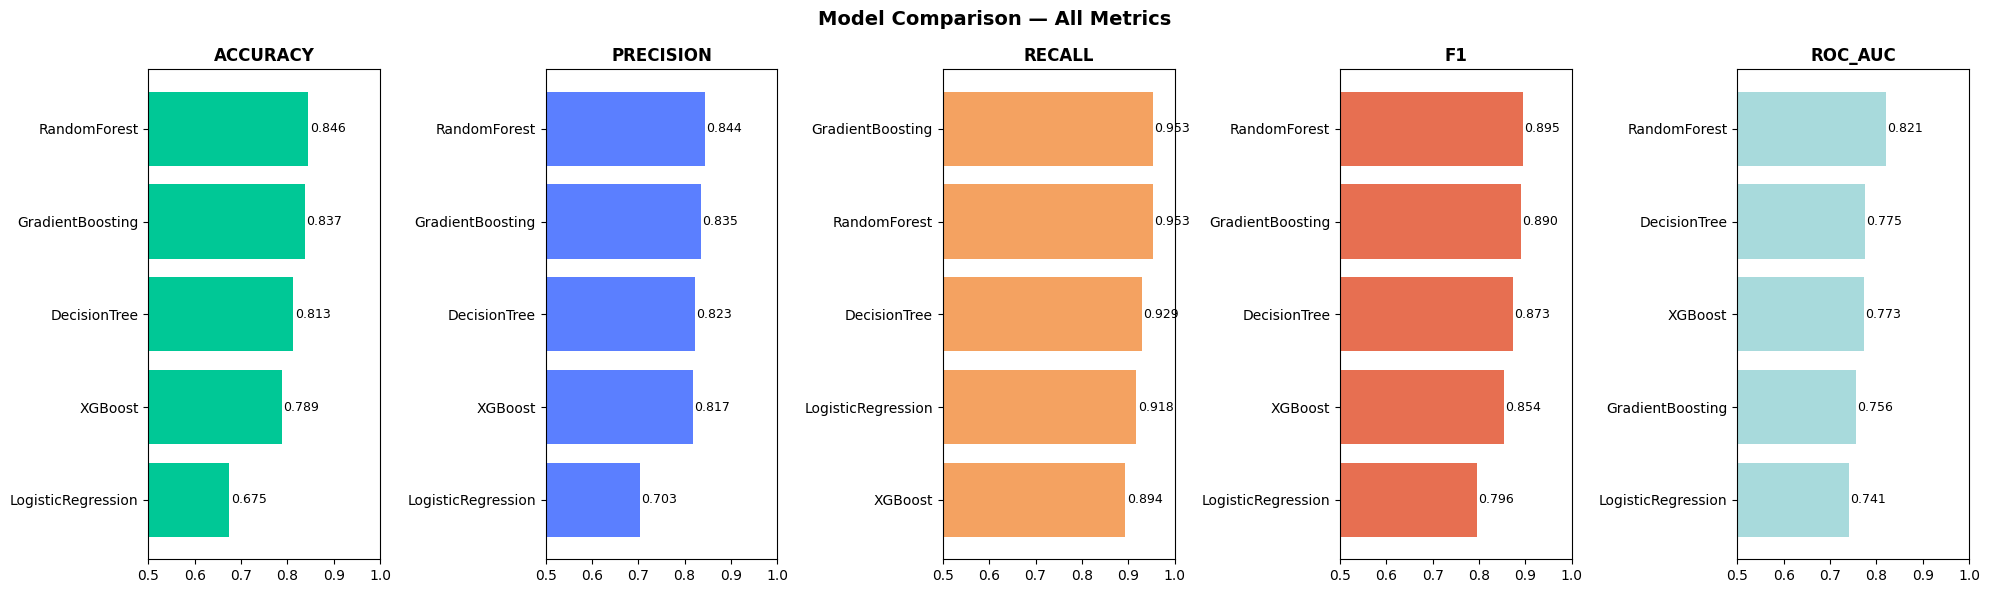

In [5]:
from trainer   import train_all_models, save_model
from evaluator import (evaluate_all_models, plot_roc_curves,
                       plot_metric_comparison)

print("Retraining all models:\n")
fitted_pipelines = train_all_models(X_train, y_train)

for name, pipeline in fitted_pipelines.items():
    save_model(pipeline, name)

results_df = evaluate_all_models(fitted_pipelines, X_val, y_val)
print("\n── Results after fix ──")
print(results_df.to_string())

plot_roc_curves(fitted_pipelines, X_val, y_val)
plot_metric_comparison(results_df)